In [ ]:
from IPython.display import HTML, display

# Configuration du design
html_content = """
<div style="
    font-family: 'Segoe UI', sans-serif;
    background: linear-gradient(120deg, #84fab0 0%, #8fd3f4 100%);
    border-radius: 15px;
    padding: 2px; /* Créer une bordure dégradée */
    box-shadow: 0 10px 25px rgba(0,0,0,0.1);
">
    <div style="
        background: white;
        border-radius: 13px;
        padding: 40px;
        text-align: center;
        position: relative;
        overflow: hidden;
    ">
        <div style="
            position: absolute; top: -50%; left: -50%; width: 200%; height: 200%;
            background: radial-gradient(circle, rgba(132,250,176,0.3) 0%, rgba(255,255,255,0) 70%);
            animation: spin 15s linear infinite;
            z-index: 0;
        "></div>
        
        <style>
            @keyframes spin { 100% { transform: rotate(360deg); } }
            @keyframes slideIn {
                from { opacity: 0; transform: translateY(20px); }
                to { opacity: 1; transform: translateY(0); }
            }
            .content-wrapper { position: relative; z-index: 1; animation: slideIn 1s ease-out; }
            .student-tag {
                display: inline-block;
                background: #f0f7ff;
                color: #333;
                padding: 10px 20px;
                margin: 8px;
                border-radius: 50px;
                font-weight: 600;
                border: 1px solid #cce4ff;
                box-shadow: 0 2px 5px rgba(0,0,0,0.05);
                transition: transform 0.2s;
            }
            .student-tag:hover { transform: scale(1.05); background: #e0efff; }
        </style>

        <div class="content-wrapper">
            <h1 style="
                margin: 0 0 10px 0;
                color: #2c3e50;
                font-size: 2.5em;
                text-transform: uppercase;
                letter-spacing: 2px;
            ">Système de Recommandation</h1>
            
            <p style="color: #7f8c8d; font-size: 1.1em; margin-bottom: 30px;">
                Projet Académique &bull; Intelligence Artificielle
            </p>

            <div style="margin-bottom: 35px;">
                <div class="student-tag">EL-OGRI ILYASS</div>
                <div class="student-tag">BOUNJA MOHAMMED AMINE</div>
                <div class="student-tag">ENNERHAIMA BOTHAYNA</div>
                <div class="student-tag">MELLAK KHADIJA</div>
            </div>

            <div style="
                border-top: 2px dashed #eee;
                padding-top: 20px;
                display: inline-block;
            ">
                <span style="color: #95a5a6; font-size: 0.9em;">SOUS L'ENCADREMENT DE</span><br>
                <strong style="color: #2c3e50; font-size: 1.3em;">Pr. ASMAA RASSIL</strong>
            </div>
        </div>
    </div>
</div>
"""

display(HTML(html_content))

# Système de Recommandation : Filtrage Basé sur le Contenu (Content-Based Filtering)

## 1. Introduction
Dans ce notebook, nous allons construire un système de recommandation basé sur le contenu en utilisant le jeu de données **Online Retail II**. 

**L'objectif :** Recommander des produits similaires à un produit donné en se basant sur sa description textuelle.

**La méthodologie :**
1. **Nettoyage des données :** Traitement des valeurs manquantes et des doublons.
2. **Traitement du langage naturel (NLP) :** Nettoyage des descriptions de produits.
3. **Extraction de caractéristiques (Feature Extraction) :** Utilisation de **TF-IDF** (Term Frequency-Inverse Document Frequency).
4. **Mesure de similarité :** Calcul de la **Similarité Cosinus**.

---

**2) Importation des Librairies**


In [ ]:
# Importation des librairies nécessaires 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Traitement de texte et vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer # Term Frequency – Inverse Document Frequency
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import linear_kernel
from collections import Counter

# Sauvegarde du Modèle 

import pickle
import os

# Configuration pour une meilleure visualisation

pd.set_option('display.max_colwidth', 100) # pour les description longues
sns.set(style="whitegrid")

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


: 

: 

**3) Chargement et Nettoyage Initial**

In [ ]:
# Chargement des données 
file_path = 'online_retail_II.csv' 

df = pd.read_csv(file_path)

print(f"Dimensions initiales du dataset : {df.shape}")

print('columns:', df.columns.tolist())


print("Aperçu des données :")
display(df.head())
print("Informations sur les données :")
df.info()

print("Statistiques descriptives (numériques) :")
display(df.describe())

print("Statistiques descriptives (catégorielles) :")
display(df.describe(include='object'))

Dimensions initiales du dataset : (1067371, 8)
columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Aperçu des données :


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
Statistiques descriptives (numériques) :


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


Statistiques descriptives (catégorielles) :


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


: 

: 

In [ ]:
has_cancellations = np.any(df['Invoice'].str.startswith('C'))
print(f"1.  des annulations ('C...') ? -> {has_cancellations} ")

# On vérifie quelques intrus classiques
garbage_codes = ['POST', 'D', 'M', 'BANK CHARGES']
has_garbage = np.any(df['StockCode'].isin(garbage_codes))
print(f"2.  des codes parasites (POST, D...) ? -> {has_garbage} ")

# 3. Y a-t-il des prix ou quantités négatifs ou nuls ?
has_negative_values = np.any((df['Quantity'] <= 0) | (df['Price'] <= 0))
print(f"3.  des valeurs négatives/nulles ? -> {has_negative_values} ")

# 4. Y a-t-il des Descriptions manquantes ?
has_missing_desc = np.any(df['Description'].isna())
print(f"4.  des descriptions manquantes ? -> {has_missing_desc} ")

print("5. Vérification des formats des codes :")
display(df[~df['StockCode'].str.match(r'^\d{5}[a-zA-Z]*$')].head())
print("6. Vérification des formats des numéros de facture :")
display(df[~df['Invoice'].str.match(r'^\d{6}$')].head())


1.  des annulations ('C...') ? -> True 
2.  des codes parasites (POST, D...) ? -> True 
3.  des valeurs négatives/nulles ? -> True 
4.  des descriptions manquantes ? -> True 
5. Vérification des formats des codes :


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.0,12682.0,France
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.0,12636.0,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.0,12362.0,Belgium
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.0,12533.0,Germany
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9.0,15299.0,United Kingdom


6. Vérification des formats des numéros de facture :


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


: 

: 

In [ ]:

#Nettoyage Avancé (Mise à jour Regex) 

# 1. Suppression des lignes où la description est manquante (Base du Content-Based)
df_clean = df.dropna(subset=['Description']).copy()

# 2. Conversion en chaînes de caractères
df_clean['Description'] = df_clean['Description'].astype(str)
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean['StockCode'] = df_clean['StockCode'].astype(str)

# 3. Filtrage  via Regex
# On ne garde que les factures valides (6 chiffres) 
df_clean = df_clean[df_clean['Invoice'].str.match(r'^\d{6}$')]

# On ne garde que les vrais produits (5 chiffres + lettres optionnelles)
# -> Vire 'POST', 'BANK CHARGES', 'M', 'D', etc.
df_clean = df_clean[df_clean['StockCode'].str.match(r'^\d{5}[a-zA-Z]*$')]

# 4. Filtrage des Quantités et Prix
# Sécurité supplémentaire : on s'assure que les quantités et prix sont positifs
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# 5. Création du catalogue de "Produits Uniques"
# Pour le Content-Based, on recommande des PRODUITS, pas des transactions.
# On garde la première occurrence de chaque couple (Code, Description)
products_df = df_clean.drop_duplicates(subset=['StockCode', 'Description'], keep='first')
products_df = products_df[['StockCode', 'Description', 'Price']].reset_index(drop=True)

print(f"Nombre de produits uniques NETTOYÉS pour l'analyse : {products_df.shape[0]}")
products_df.head()

Nombre de produits uniques NETTOYÉS pour l'analyse : 5588


,StockCode,Description,Price
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,6.95
1,79323P,PINK CHERRY LIGHTS,6.75
2,79323W,WHITE CHERRY LIGHTS,6.75
3,22041,"RECORD FRAME 7"" SINGLE SIZE",2.10
4,21232,STRAWBERRY CERAMIC TRINKET BOX,1.25


: 

: 

In [ ]:
has_cancellations = np.any(df_clean['Invoice'].str.startswith('C'))
print(f"1. Reste-t-il des annulations ('C...') ? -> {has_cancellations} ")

# On vérifie quelques intrus classiques
garbage_codes = ['POST', 'D', 'M', 'BANK CHARGES']
has_garbage = np.any(df_clean['StockCode'].isin(garbage_codes))
print(f"2. Reste-t-il des codes parasites (POST, D...) ? -> {has_garbage} ")

# 3. Y a-t-il des prix ou quantités négatifs ou nuls ?
has_negative_values = np.any((df_clean['Quantity'] <= 0) | (df_clean['Price'] <= 0))
print(f"3. Reste-t-il des valeurs négatives/nulles ? -> {has_negative_values} ")

# 4. Y a-t-il des Descriptions manquantes ?
has_missing_desc = np.any(df_clean['Description'].isna())
print(f"4. Reste-t-il des descriptions manquantes ? -> {has_missing_desc} ")



1. Reste-t-il des annulations ('C...') ? -> False 
2. Reste-t-il des codes parasites (POST, D...) ? -> False 
3. Reste-t-il des valeurs négatives/nulles ? -> False 
4. Reste-t-il des descriptions manquantes ? -> False 


: 

: 

## 4) Analyse Exploratoire des Données (EDA)

Avant de modéliser, visualisons les données textuelles. Nous allons analyser les mots les plus fréquents.

In [ ]:

#Analyse des mots les plus fréquents (Top 20)


# Concaténer tout le texte
all_text = " ".join(products_df['Description'].str.lower())


# Séparer par mot
words = all_text.split()
print(words[:20])  # Afficher les 20 premiers mots pour vérification

# Compter
word_counts = Counter(words) # c'est une classe qui prend en entréé un itérable et compte la fréquence de chaque élément


common_words = word_counts.most_common(20) # methode de la classe Counter qui retourne les n éléments les plus communs sous forme de liste de tuples (mot, fréquence)

# Création du DataFrame pour le plot
words_df = pd.DataFrame(common_words, columns=['Mot', 'Fréquence'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Fréquence', y='Mot', data=words_df, palette='viridis')
plt.title('Top 20 des mots les plus fréquents dans les descriptions', fontsize=15)
plt.show()

NameError: name 'products_df' is not defined

: 

: 

## 5). Extraction de Caractéristiques : TF-IDF

Pour calculer la similarité, nous devons transformer le texte en vecteurs mathématiques. Nous utilisons la méthode **TF-IDF**.

### Formule Mathématique

Le poids TF-IDF d'un terme $t$ dans un document $d$ est donné par :

$$w_{t,d} = TF(t,d) \times IDF(t)$$

Où :
1.  **Term Frequency (TF)** : Fréquence du terme dans le document.
    $$TF(t,d) = \frac{\text{nombre d'occurrences de } t \text{ dans } d}{\text{nombre total de mots dans } d}$$

2.  **Inverse Document Frequency (IDF)** : Mesure l'importance du terme dans l'ensemble du corpus.
    $$IDF(t) = \log \left( \frac{N}{1 + |\{d \in D : t \in d\}|} \right)$$
    * $N$ : Nombre total de documents (produits).
    * Le dénominateur : Nombre de documents contenant le terme $t$.

Cela permet de réduire l'importance des mots très courants (comme "THE", "OF") et d'augmenter celle des mots rares et spécifiques.



## 6) Pré-traitement et Vectorisation

In [ ]:
# Prétraitement du texte 
def clean_text(text):
    text = text.lower()  # Minuscules
    text = re.sub(r'\[.*?\]', '', text) # Enlever ce qui est entre crochets
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Enlever ponctuation
    return text

products_df['clean_description'] = products_df['Description'].apply(clean_text)

print("Exemple de description nettoyée :")
print(f"Original : {products_df['Description'].iloc[0]}")
print(f"Nettoyé  : {products_df['clean_description'].iloc[0]}")

#  Vectorisation TF-IDF 
# On ignore les mots qui apparaissent dans plus de 95% des docs ou moins de 2 docs
tfidf = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2)

# Construction de la matrice TF-IDF
tfidf_matrix = tfidf.fit_transform(products_df['clean_description'])

print(f"\nDimensions de la matrice TF-IDF : {tfidf_matrix.shape}")
print("(Nombre de produits, Nombre de mots uniques)")

Exemple de description nettoyée :
Original : 15CM CHRISTMAS GLASS BALL 20 LIGHTS
Nettoyé  : 15cm christmas glass ball 20 lights

Dimensions de la matrice TF-IDF : (5588, 1527)
(Nombre de produits, Nombre de mots uniques)


: 

: 

In [ ]:
# Exemple de transformation d'une description en vecteur TF-IDF 
text = products_df['clean_description'].iloc[0]
print(text)

#TfidfVectorizer ne retourne pas directement un array lisible, mais une matrice sparse.
vector = tfidf.transform([text])

print(type(vector))        # sparse matrix

print(vector.shape)       # (1, nombre_de_mots)

vector_array = vector.toarray()[0]
print(vector_array)
print(vector_array.mean()) #ca prouve que la plupart des valeurs sont proches de 0, comme attendu dans une matrice TF-IDF.


15cm christmas glass ball 20 lights
<class 'scipy.sparse._csr.csr_matrix'>
(1, 1527)
[0. 0. 0. ... 0. 0. 0.]
0.001558924103553268


: 

: 

In [ ]:
def plot_top_tfidf_words(tfidf_matrix, feature_names, top_n=20):
    """
    Affiche les mots avec les scores TF-IDF moyens les plus élevés
    """
    mean_tfidf = tfidf_matrix.mean(axis=0).A1 # axis = 0 : moyenne pour chaque mot sur tous les produits, résultat : score TF-IDF de chaque mot dans tout le catalogue
    # A1 : conversion en tableau 1D plus facile à manipuler
    # on calcule l’importance moyenne de chaque mot dans tout le corpus
    
    top_indices = np.argsort(mean_tfidf)[-top_n:]

    plt.figure(figsize=(10, 5))
    plt.barh(
        [feature_names[i] for i in top_indices],
        mean_tfidf[top_indices]
    )
    plt.xlabel("Score TF-IDF moyen")
    plt.title("Top mots TF-IDF")
    plt.tight_layout()
    plt.show()


: 

: 

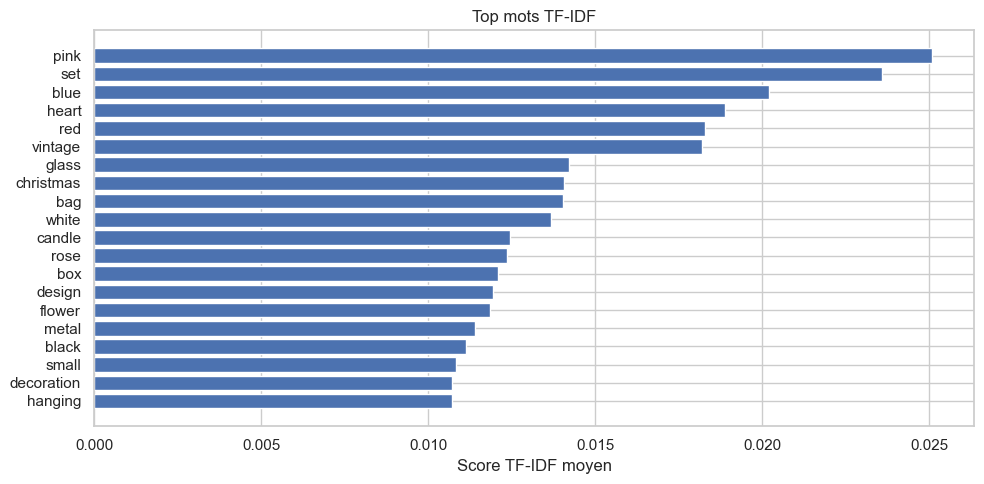

: 

: 

In [ ]:
feature_names = tfidf.get_feature_names_out()

plot_top_tfidf_words(tfidf_matrix, feature_names)


## 7) Calcul de la Similarité Cosinus

Une fois nos produits représentés sous forme de vecteurs dans un espace multidimensionnel, nous calculons la similarité entre eux en utilisant le **Cosinus de l'angle** entre ces vecteurs.

### Formule Mathématique

La similarité cosinus entre deux vecteurs $A$ (Produit 1) et $B$ (Produit 2) est définie par :

$$\text{similarity}(A, B) = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

* Si l'angle est 0°, le cosinus est 1 (les produits sont identiques).
* Si l'angle est 90°, le cosinus est 0 (les produits n'ont rien en commun).

## 8) Calcul de la Matrice de Similarité

In [ ]:
# Calcul de la similarité cosinus 
# Puisque nous avons utilisé TF-IDF, le produit scalaire (linear_kernel) est équivalent 
# à la similarité cosinus et est plus rapide à calculer.


# Calcul de la matrice de similarité (N x N)
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

print(f"Dimensions de la matrice de similarité : {cosine_sim.shape}")
print("Exemple de score de similarité entre le produit 0 et le produit 1 :", cosine_sim[0, 1])

Dimensions de la matrice de similarité : (5588, 5588)
Exemple de score de similarité entre le produit 0 et le produit 1 : 0.2583915890984148


: 

: 

**Visualisation de la Matrice de Similarité (Heatmap)**

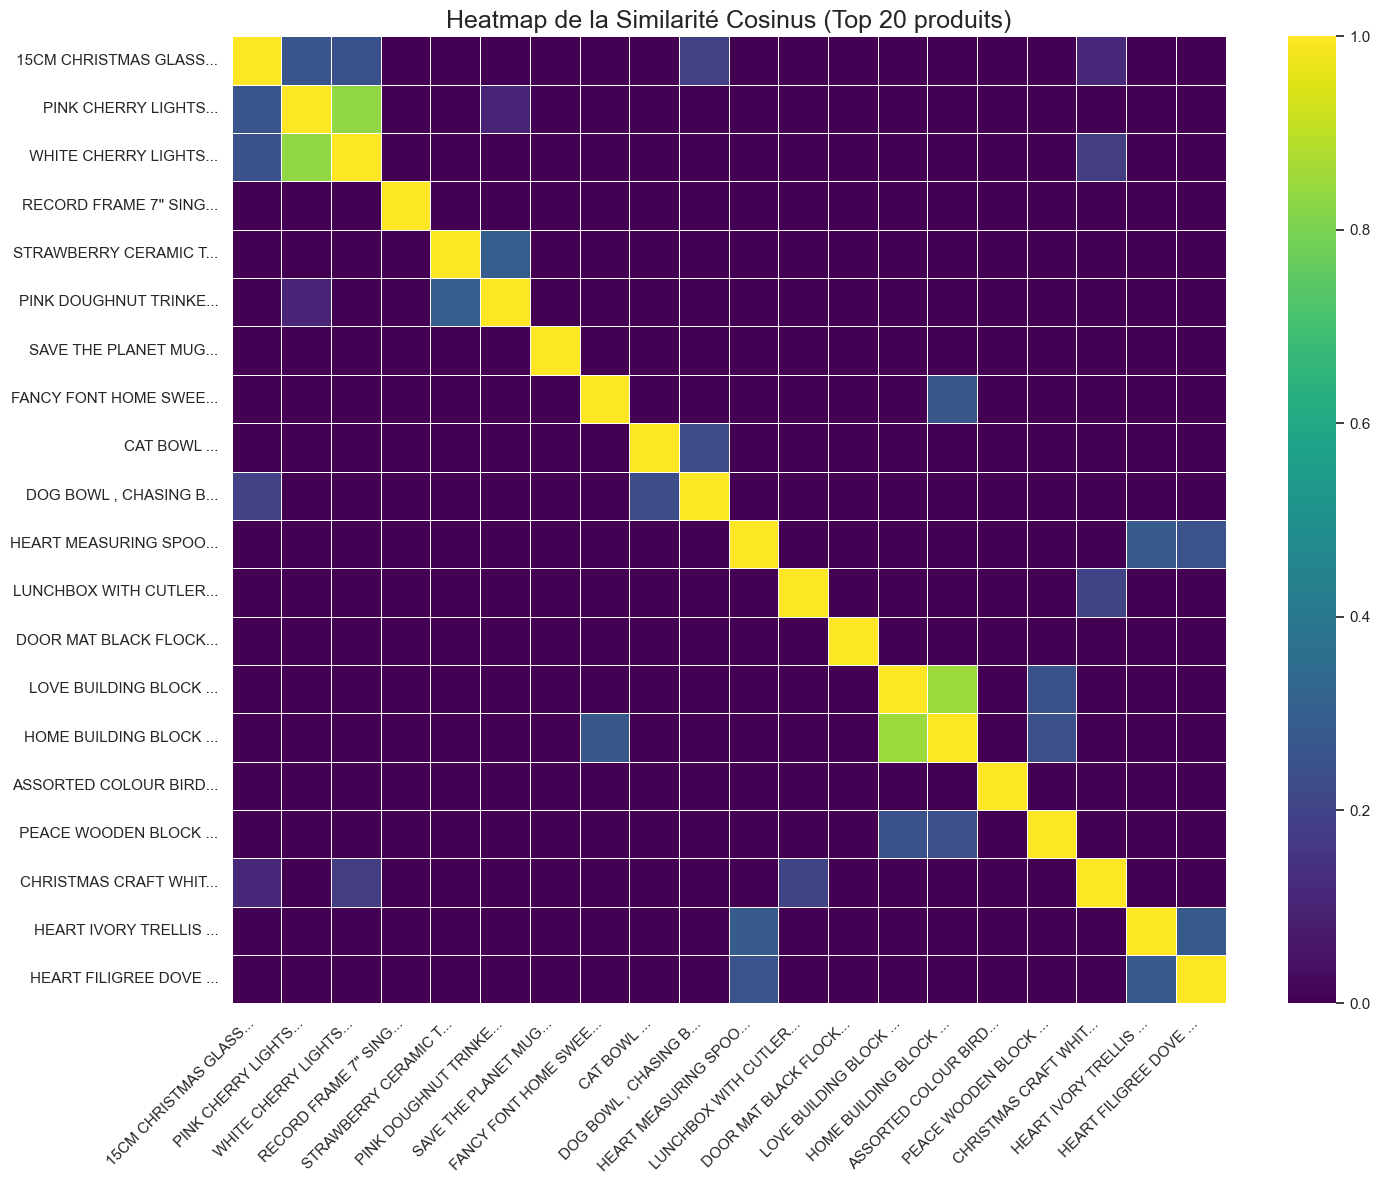

: 

: 

In [ ]:
# Visualisation de la Matrice de Similarité 

# On sélectionne un sous-ensemble de 20 produits pour la lisibilité
# On prend les 20 premiers produits du dataframe filtré
subset_size = 20
subset_sim = cosine_sim[:subset_size, :subset_size]
subset_labels = products_df['Description'].iloc[:subset_size].apply(lambda x: x[:20] + '...') # On tronque les noms trop longs

plt.figure(figsize=(15, 12))

# Création de la Heatmap
sns.heatmap(
    subset_sim, 
    xticklabels=subset_labels, 
    yticklabels=subset_labels, 
    cmap='viridis', 
    annot=False, 
    linewidths=0.5
)

plt.title(f'Heatmap de la Similarité Cosinus (Top {subset_size} produits)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9) Sauvegarde du Modèle (Pickle)
Nous allons utiliser pickle pour sérialiser (sauvegarder) les objets Python. Nous créons un dossier models/ s'il n'existe pas. Nous sauvegardons :

Le DataFrame des produits (pour avoir les noms et ID).

La matrice de similarité (le "cerveau" du modèle).

In [ ]:
# Sauvegarde du Modèle 


# 1. Création du dossier 'models' s'il n'existe pas
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Dossier '{model_dir}' créé.")


indices = pd.Series(products_df.index, index=products_df['Description']).drop_duplicates()

print("Variable 'indices' régénérée.")

# 2. Préparation des données à sauvegarder
# On sauvegarde le DataFrame, la matrice et le mapping des indices
data_to_save = {
    'products_df': products_df,
    'cosine_sim': cosine_sim,
    'indices': indices
}

# 3. Chemin du fichier
file_path = os.path.join(model_dir, 'content_based_model.pkl')

# 4. Sauvegarde
try:
    with open(file_path, 'wb') as f:
        pickle.dump(data_to_save, f)
    print(f"Modèle sauvegardé avec succès dans : {file_path}")
    
except Exception as e:
    print(f"Erreur lors de la sauvegarde : {e}")

Variable 'indices' régénérée.
Modèle sauvegardé avec succès dans : models\content_based_model.pkl


: 

: 

## 10) Conclusion

Nous avons construit avec succès un moteur de recommandation **Content-Based** et exporté le modèle pour une utilisation future.

**Points Clés :**
* Le système analyse sémantiquement les descriptions pour trouver des liens non triviaux.
* Il ne nécessite aucune donnée sur les utilisateurs (idéal pour le "Cold Start").
* La matrice de similarité a été validée visuellement via une Heatmap.

**Prochaines étapes :**

* Passer au notebook suivant pour explorer le **Filtrage Collaboratif** (Collaborative Filtering) basé sur le comportement des clients.